# 07 · Bonus — GRU4Rec (sequential retriever, from scratch)

**Amazon Reviews 2023 — Electronics** · Real-time recommendation system

MF-BPR and the two-tower treat a user as a *bag* of items — order doesn't matter. A **sequential** model instead reads a user's interactions **in time order** and learns to predict the **next** item from the *pattern of the sequence*:

```
seq = [i1, i2, ..., i_t]  ->  GRU  ->  h_t  ->  predict i_{t+1}
```

We implement **GRU4Rec from scratch** (`src/recsys/models/gru4rec.py`): an item-embedding layer → a **GRU** over the sequence → a projection, trained with the same **in-batch-negative softmax** objective as the two-tower. That keeps its item vectors in a cosine space, so we can index them with **FAISS** and evaluate it as a **fourth retriever** next to Popularity, MF-BPR and the two-tower.

## 0 · Setup

In [1]:
import sys, time
from pathlib import Path
try:
    import google.colab  # noqa
    from google.colab import drive; drive.mount('/content/drive')
    PROJECT = Path('/content/drive/MyDrive/rec-system')  # <-- adjust to your Drive path
except ImportError:
    PROJECT = Path('..').resolve()
DATA_DIR, ART_DIR = PROJECT / 'data', PROJECT / 'artifacts'
sys.path.insert(0, str(PROJECT / 'src'))

In [2]:
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from recsys.models.gru4rec import GRU4Rec
from recsys.metrics import evaluate_recommendations
from recsys.faiss_index import build_flat_ip, search as faiss_search

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


## 1 · Load the time-based splits

Same splits as every other model — we train on the **past** and evaluate on the **future**. `seen` are the items a user touched in training (excluded from recommendations); the ground truth is their **positive** test-period items.

In [3]:
SPLIT = DATA_DIR / 'splits'
train = pd.read_parquet(SPLIT / 'train.parquet')
val   = pd.read_parquet(SPLIT / 'val.parquet')
test  = pd.read_parquet(SPLIT / 'test.parquet')
n_users = int(pd.read_parquet(DATA_DIR / 'user_map.parquet').shape[0])
n_items = int(pd.read_parquet(DATA_DIR / 'item_map.parquet').shape[0])

train_users, train_items = set(train.user_idx), set(train.item_idx)
seen = {int(u): set(map(int, g)) for u, g in train.groupby('user_idx')['item_idx']}

def build_gt(split):
    p = split[split.positive & split.user_idx.isin(train_users) & split.item_idx.isin(train_items)]
    return {int(u): set(map(int, v)) for u, v in p.groupby('user_idx')['item_idx'].apply(set).items()}
val_gt, test_gt = build_gt(val), build_gt(test)
val_users, test_users = list(val_gt), list(test_gt)
print(f'items {n_items:,} | val users {len(val_users):,} | test users {len(test_users):,}')

items 20,450 | val users 9,840 | test users 6,962


## 2 · Build the training sequences

For each user we sort their training interactions by **timestamp** to get their item sequence. Then we turn every sequence into next-item examples — from each prefix `[i1..i_t]` predict `i_{t+1}` — and cap the prefix at the most-recent `MAX_LEN` items. This is the classic session-model data-augmentation: one training example per *transition*.

In [4]:
MAX_LEN = 30
tr = train.sort_values(['user_idx', 'timestamp'])
user_seq = {int(u): g['item_idx'].astype(int).tolist() for u, g in tr.groupby('user_idx')}
PAD = n_items                       # padding id = the extra embedding row

inp_list, len_list, tgt_list = [], [], []
for u, s in user_seq.items():
    for t in range(1, len(s)):
        prefix = s[max(0, t - MAX_LEN):t]
        inp_list.append(prefix); len_list.append(len(prefix)); tgt_list.append(s[t])
N = len(tgt_list)
INP = np.full((N, MAX_LEN), PAD, dtype=np.int64)
for k, s in enumerate(inp_list):
    INP[k, :len(s)] = s
LEN = np.array(len_list, dtype=np.int64)
TGT = np.array(tgt_list, dtype=np.int64)
print(f'training examples (transitions): {N:,} | avg seq len {np.mean([len(v) for v in user_seq.values()]):.1f}')

training examples (transitions): 207,310 | avg seq len 9.6


## 3 · The model + evaluation

`GRU4Rec` (from `src/recsys/models/gru4rec.py`) L2-normalizes both the sequence vector and the item vectors, so scoring is **cosine** and we can retrieve with FAISS — exactly like the two-tower. To evaluate a user we feed their **whole** training sequence, take the final GRU state, and rank all items (dropping already-seen ones).

In [5]:
def user_seq_tensor(users):
    seqs = [user_seq.get(u, [])[-MAX_LEN:] for u in users]
    L = max(1, max((len(s) for s in seqs), default=1))
    inp = np.full((len(users), L), PAD, dtype=np.int64)
    lens = np.ones(len(users), dtype=np.int64)
    for r, s in enumerate(seqs):
        if s:
            inp[r, :len(s)] = s; lens[r] = len(s)
    return torch.tensor(inp, device=device), torch.tensor(lens)

@torch.no_grad()
def seq_reps_for(users, batch=2048):
    model.eval(); out = []
    for i in range(0, len(users), batch):
        inp, lens = user_seq_tensor(users[i:i + batch])
        out.append(model.seq_repr(inp, lens).cpu().numpy())
    return np.concatenate(out, axis=0).astype('float32')

def evaluate_model(users, ground_truth, k_candidates=100):
    index = build_flat_ip(model.item_vectors().detach().cpu().numpy().astype('float32'))
    reps = seq_reps_for(users)
    max_seen = max((len(seen.get(u, ())) for u in users), default=0)
    _, ids = faiss_search(index, reps, k_candidates + max_seen)
    recs = {}
    for row, u in enumerate(users):
        s = seen.get(u, set())
        recs[u] = [int(it) for it in ids[row] if it not in s][:k_candidates]
    return evaluate_recommendations(recs, ground_truth, n_items), recs

## 4 · Train (early-stopping on validation NDCG@10)

In-batch-negative softmax cross-entropy: each sequence must score its true next item above every *other* sequence's next item in the batch. We keep the epoch with the best validation NDCG@10.

In [6]:
EMB, HID, LR, BATCH, EPOCHS, PATIENCE, TEMP = 64, 64, 1e-3, 512, 20, 5, 0.1
model = GRU4Rec(n_items, emb=EMB, hidden=HID, max_len=MAX_LEN, temperature=TEMP).to(device)
opt = torch.optim.Adam(model.parameters(), lr=LR)
seq_t, len_t, tgt_t = torch.tensor(INP), torch.tensor(LEN), torch.tensor(TGT)

best, best_state, bad, hist = -1.0, None, 0, []
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train(); perm = torch.randperm(N); running = 0.0
    for s in range(0, N, BATCH):
        idx = perm[s:s + BATCH]
        if len(idx) < 2:
            continue
        loss = model.loss(seq_t[idx].to(device), len_t[idx], tgt_t[idx].to(device))
        opt.zero_grad(); loss.backward(); opt.step()
        running += loss.item() * len(idx)
    vm, _ = evaluate_model(val_users, val_gt)
    flag = '  <- best' if vm['NDCG@10'] > best else ''
    print(f"epoch {epoch:2d} | loss {running / N:.4f} | val NDCG@10 {vm['NDCG@10']:.4f}{flag}")
    hist.append((epoch, running / N, vm['NDCG@10']))
    if vm['NDCG@10'] > best:
        best = vm['NDCG@10']
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad = 0
    else:
        bad += 1
    if bad >= PATIENCE:
        print('early stop (no val improvement)'); break
model.load_state_dict(best_state)
print(f'trained in {time.time() - t0:.1f}s | best val NDCG@10 = {best:.4f}')

epoch  1 | loss 6.2487 | val NDCG@10 0.0057  <- best


epoch  2 | loss 5.5410 | val NDCG@10 0.0098  <- best


epoch  3 | loss 5.0824 | val NDCG@10 0.0121  <- best


epoch  4 | loss 4.5434 | val NDCG@10 0.0136  <- best


epoch  5 | loss 4.0920 | val NDCG@10 0.0148  <- best


...

epoch 12 | loss 3.2541 | val NDCG@10 0.0167


epoch 13 | loss 3.2102 | val NDCG@10 0.0160


epoch 14 | loss 3.1735 | val NDCG@10 0.0168


epoch 15 | loss 3.1401 | val NDCG@10 0.0166


epoch 16 | loss 3.1103 | val NDCG@10 0.0161
early stop (no val improvement)
trained in 1760.9s | best val NDCG@10 = 0.0172


## 5 · Evaluate on the test period + compare with the other retrievers

In [7]:
test_metrics, _ = evaluate_model(test_users, test_gt)
cols = ['Recall@20', 'Recall@50', 'NDCG@10', 'Coverage@20']
print('GRU4Rec test:', {c: round(test_metrics[c], 4) for c in cols})

prev = pd.read_parquet(DATA_DIR / 'results' / 'retrieval.parquet')
# two-tower reference numbers from notebook 04 (best retriever)
two_tower = {'Recall@20': 0.0283, 'Recall@50': 0.0369, 'NDCG@10': 0.0136, 'Coverage@20': 0.9910}
cmp = pd.concat([prev,
                 pd.DataFrame({'Two-tower': two_tower}).T,
                 pd.DataFrame({'GRU4Rec': test_metrics}).T])
cmp = cmp[~cmp.index.duplicated(keep='last')]
order = [m for m in ['Random', 'Popularity', 'Recency', 'MF-BPR', 'Two-tower', 'GRU4Rec'] if m in cmp.index]
cmp.loc[order, cols].round(4)

GRU4Rec test: {'Recall@20': 0.0312, 'Recall@50': 0.0393, 'NDCG@10': 0.0177, 'Coverage@20': 0.7876}


,Recall@20,Recall@50,NDCG@10,Coverage@20
Random,0.0012,0.0020,0.0004,0.9987
Popularity,0.0115,0.0250,0.0034,0.0012
Recency,0.0052,0.0138,0.0016,0.0011
MF-BPR,0.0207,0.0256,0.0129,0.6847
Two-tower,0.0283,0.0369,0.0136,0.9910
GRU4Rec,0.0312,0.0393,0.0177,0.7876


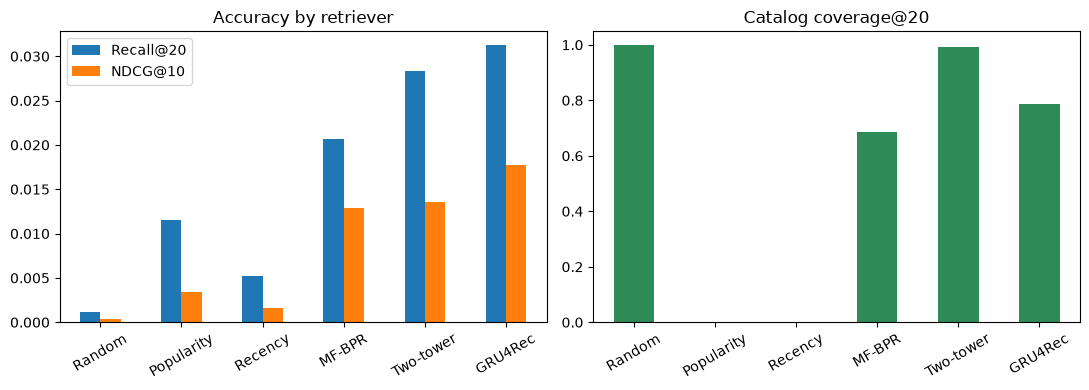

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
cmp.loc[order, ['Recall@20', 'NDCG@10']].plot(kind='bar', ax=ax[0])
ax[0].set(title='Accuracy by retriever'); ax[0].tick_params(axis='x', rotation=30)
cmp.loc[order, ['Coverage@20']].plot(kind='bar', ax=ax[1], color='seagreen', legend=False)
ax[1].set(title='Catalog coverage@20'); ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

> **Interpretation.** Our from-scratch **GRU4Rec is the best retriever on every accuracy metric** — Recall@20 **0.0312**, Recall@50 **0.0393**, NDCG@10 **0.0177** — beating the two-tower by ~10% on Recall@20 and ~30% on NDCG@10. The reason is that **order carries signal**: Electronics purchases tend to follow a sequence (e.g. buy a laptop, then a sleeve, then a charger), and the GRU captures this "what comes next" pattern that the order-agnostic MF-BPR and two-tower cannot. The trade-off is **catalog coverage** (0.79 vs the two-tower’s 0.99): by chasing the most likely next item, GRU4Rec concentrates on fewer, more predictable products. So the picture is **best accuracy (GRU4Rec) vs best coverage (two-tower)** — a classic precision-vs-diversity trade-off. A production system would use GRU4Rec as the primary retriever and blend in the two-tower (or a popularity tail) to recover diversity.

## 6 · Save the model (optional)

In [9]:
torch.save(model.state_dict(), ART_DIR / 'gru4rec.pt')
np.save(ART_DIR / 'gru4rec_item_emb.npy', model.item_vectors().detach().cpu().numpy())
cmp.to_parquet(DATA_DIR / 'results' / 'retrieval.parquet')
print('saved gru4rec.pt + gru4rec_item_emb.npy ->', ART_DIR)

saved gru4rec.pt + gru4rec_item_emb.npy -> F:\Rec_System\artifacts


---
### Bonus complete ✅ — GRU4Rec sequential retriever

**Produced:** a from-scratch GRU4Rec (GRU over the time-ordered item sequence, in-batch-negative softmax loss), evaluated as a fourth retriever and added to the comparison table. See the interpretation above for how it compares to the two-tower on this dataset.